## **Group 9 - Mid-term Project Guideline Step Two**
### *Team: Bryan Larison • Gina Fuller • Alexandra Hagen • Garrett Williford*

# ***What brews a winning cup?***

### **1. Introduction**

Coffee is not just a drink — it is an experience shaped by dozens of factors, from the altitude where the beans are grown to the way they are processed and roasted. Some coffees earn exceptional scores, but what exactly makes them stand out from the rest? In this project, we aim to answer the question: ***“What brews a winning cup?”*** By exploring key variables like country of origin, processing methods, altitude, and sensory attributes such as flavor, aroma, and acidity, we can uncover the elements that define top-quality coffee. This data-driven approach blends curiosity with caffeine to reveal the recipe for a truly standout brew.

### **2. Required Packages**

Determining what packages to install is quite possibly the most important step in any project involving coding. 
The following packages for our group's project were installed:

**pandas** - There are a myriad of ways to clean and manipulate data, but pandas is the go-to fundamental package in Python for data wrangling projects; and ours is no exception. 

**numpy** - Numpy is a package that enables the storage and manipulation of numerical data compiled in datasets with advanced mathematical functions.

**scipy** - Scypy is a package that expands the mathematical functions of numpy providing additional tools for array operations.

**matplotlib.pyplot** - Matplotlib.pyplot is a package that enables the customization and display of plots of scientific data

**seaborn** - Seaborn is a package that expands the functions of matplotlib.pyplot for advanced statistical analysis visualization. 

In [5]:
!pip install scipy

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### **3. Data Preparation**

These data were collected from the Coffee Quality Institute's (CQI) review pages in January 2018 by Buzzfeed Data Scientist James Ledoux for the purpose of digitizing 1340 coffee reviews by CQI's trained reviewers. The reviews are of 1312 arabica and 28 robusta coffee beans from all over the world. This dataset is open access and can be found at https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-07-07/readme.md

The data compiled into this dataset includes: quality measures (aroma, flavor, aftertaste, acidity, body, balance, uniformity, cup, cleanliness, sweetness, moisture, and defects), bean metadata (quality, color, species (arabica/robusta), and farm metadata (owner, country of origin, farm name, lot number, mill, company, altitude, and region), divided into separate columns. Some features were broken down even further and assigned their own columns as well, leaving the total number of columns in this dataset to be 43.

Based on the hypotheses made among us, there are quite a few columns in this dataset that may be considered irrelevant to what it is we are attempting to determine; that which is, the makings of a high-quality coffee.    

Data cleaning is necessary and essential for data analysis because it ensures accuracy, consistency, and reliability. This reduces skewed and inaccurate results, which in turn leads to much more effective decision making. In the case of our project, our findings could potentially aid the consumer in selecting the highest-quality coffee for their money.  

The most frequently utilized library in Python for data cleaning and manipulation is the pandas library. Of course the most important code for our project, first and foremost, was pd.csv_read() to import the coffee.csv dataset into our notebooks to initiate our data preparation. For our project, the bare minimum we needed were tools to do away with any data we deemed not applicable to answering our questions for us to even begin our data analysis. For this part of the cleaning .drop() and .dropna() helped us get the job done. 

Once all extraneous data was dropped - to include nan values in some cases - this is where we each went our separate ways to organize the data we regarded necessary to answer our questions and to visually present our findings.  

The most important variable in our project is of course, the main DataFrame for our project, 
df = pd.read_csv("coffee_ratings.csv"). Without this variable, we would have nothing to work off of. Next, would be the final variables that our visuals are derived from. These include: 

**FIGURE 1 - Total Sensory Scores - Min, Max, and Top Cutoff**

scores = df_sorted['total_sensory_score']; 

**FIGURE 2 - Top 3 Sensory Attributes - Correlation Strength**

corrs = top[attrs].corrwith(top["total_cup_points"]).sort_values(ascending=True); 

**FIGURE 3 - Flavor Score Distribution by Harvest Year**

df['flavor'] = pd.to_numeric(df['flavor'], errors='coerce');

**FIGURE 4 - Mean Flavor Score by Processing Method**

method_stats = (df.groupby("processing_method")["flavor"].agg(mean_flavor="mean", n="count").sort_values("mean_flavor", ascending=False)) 

**FIGURE 5 - Flavor Score Distribution by Altitude Band**

data = [keep.loc[keep["alt_band"] == lab, "flavor"].dropna().values for lab in labels];

**FIGURE 6 - Coffee Samples from Countries with Altitudes ≥1600 m**

country_counts = high_alt["country"].value_counts().sort_values(ascending=False).

Without these variables derived from the main DataFrame through various methods and numerous intermediate steps, and the main DataFrame itself, the following charts for our project visualization would not have been made possible.

### ***Which sensory attribute has the strongest impact on total cup points (overall rating)?***

#### **Step 1 - Determine the cutoff of the the top 10% coffee based on total sensory values**
The values of the sensory attributes — aroma, flavor, aftertaste, acidity, body, balance, and sweetness — for each coffee were summed into single values. These resulting values were designated as 'total sensory scores'. The distribution of the total sensory scores was then plotted to display the full sensory score range of all the coffees in the dataset. Our goal in presenting this spread was to make the cutoffs visible (e.g., bottom 10%, middle, top 10%) with the intention of identifying the cutoff point (e.g., top 10%) that distinguishes the best coffee from the average.

In [7]:
# --- Load and clean data ---
df = pd.read_csv("coffee_ratings.csv")

sensory_attrs = ["aroma","flavor","aftertaste","acidity","body","balance","sweetness"]
sensory_data = df[sensory_attrs].apply(pd.to_numeric, errors='coerce')
df['total_sensory_score'] = sensory_data.sum(axis=1)
df = df.dropna(subset=['total_sensory_score'])

# Sort scores ascending for a nice visual
df_sorted = df.sort_values('total_sensory_score', ascending=True).reset_index(drop=True)
scores = df_sorted['total_sensory_score']

# Cutoff (90th percentile)
cutoff = scores.quantile(0.90)
min_val = scores.min()
max_val = scores.max()

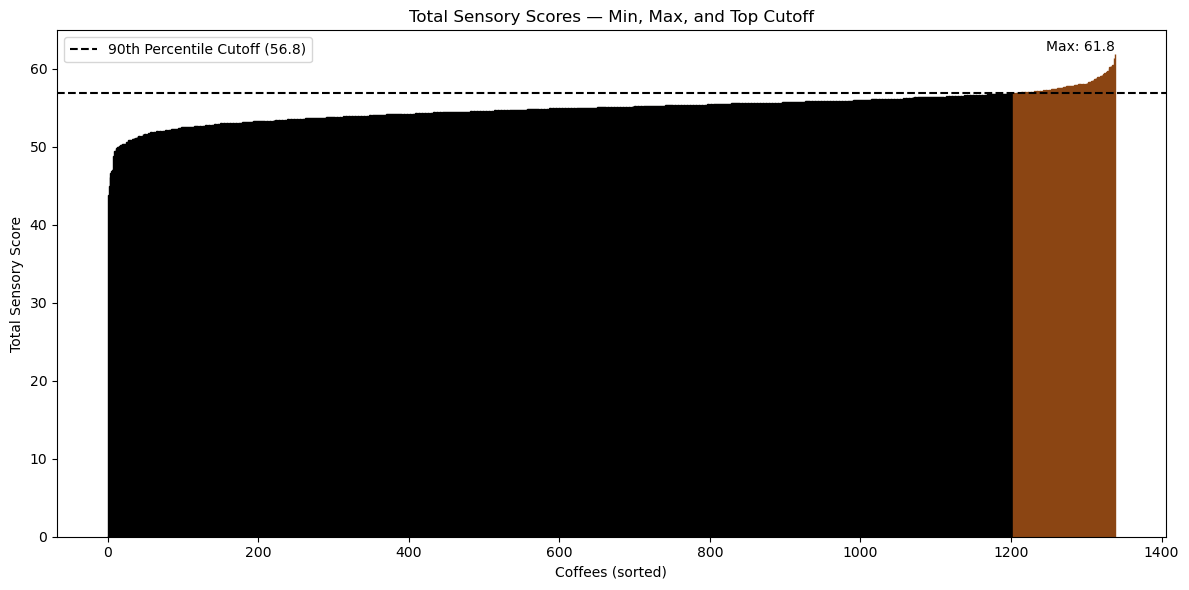

In [8]:
# --- Bar chart ---
plt.figure(figsize=(12,6))
bars = plt.bar(range(len(scores)), scores, color="tan", edgecolor="black")

# Highlight top 10%
for i, score in enumerate(scores):
    if score >= cutoff:
        bars[i].set_color("saddlebrown")

# Add cutoff line
plt.axhline(cutoff, color="black", linestyle="--", label=f'90th Percentile Cutoff ({cutoff:.1f})')

# Labels & formatting
plt.title("Total Sensory Scores — Min, Max, and Top Cutoff")
plt.xlabel("Coffees (sorted)")
plt.ylabel("Total Sensory Score")
plt.text(0, min_val, f"Min: {min_val:.1f}", va='bottom', ha='left')
plt.text(len(scores)-1, max_val, f"Max: {max_val:.1f}", va='bottom', ha='right')
plt.legend()
plt.tight_layout()
plt.show()

##### **FIGURE 1: Total Sensory Scores - Min, Max, and Top Cutoff**
The distribution chart above presents the full range of total sensory scores for all the coffees in the dataset, sorted from lowest to highest. The dashed line represents the 90th percentile cutoff, while everything above it represents the top-performing coffees. These top coffees are highlighted in brown, making it easy to distinguish where the top group begins to split off from the rest. The sensory scores for coffees in the 90th percentile begin at 56.8.

#### **Step 2 - Identify the top sensory attributes of the top 10% coffee**
Now that we have established 56.8 as the 90th percentile cutoff for total sensory scores, we went on to evaluate the each individual sensory attribute for the top 10% coffees only. This focused our analysis on what actually separates the best coffees from each other, not from average ones. Attributes with small IQRs did not separate winners.

In [9]:
# --- Create variable sensory ---
sensory = ["aroma","flavor","aftertaste","acidity","body","balance","sweetness"]

# Convert sensory columns to numeric
S = df[sensory].apply(pd.to_numeric, errors="coerce")
S = S.dropna(how="any")

# Calculate total sensory score
S['total_sensory_score'] = S.sum(axis=1)

# --- Filter for top 10% coffees ---
cutoff = 56.8
top_coffees = S[S['total_sensory_score'] >= cutoff].copy()

# --- Recalculate variability ---
summary_rows = []
for a in sensory:
    s = top_coffees[a].dropna()
    summary_rows.append({
        "attribute": a,
        "count": s.size,
        "min": s.min(),
        "q1": s.quantile(0.25),
        "median": s.quantile(0.50),
        "q3": s.quantile(0.75),
        "max": s.max(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "mean": s.mean(),
        "std": s.std(ddof=0)
    })

top_summary = (pd.DataFrame(summary_rows)
               .sort_values(["iqr","std"], ascending=False)
               .reset_index(drop=True))

# Format for clean display
top_summary.style.format({
    "min":"{:.2f}","q1":"{:.2f}","median":"{:.2f}","q3":"{:.2f}","max":"{:.2f}",
    "iqr":"{:.2f}","mean":"{:.2f}","std":"{:.2f}"
})

,attribute,count,min,q1,median,q3,max,iqr,mean,std
0,aroma,149,7.42,7.83,8.00,8.17,8.75,0.34,8.01,0.25
1,flavor,149,7.50,7.83,8.00,8.17,8.83,0.34,8.04,0.24
2,acidity,149,7.17,7.83,8.00,8.17,8.75,0.34,8.02,0.24
3,aftertaste,149,7.25,7.75,7.83,8.00,8.67,0.25,7.91,0.24
4,body,149,7.38,7.75,7.92,8.00,8.58,0.25,7.91,0.23
5,balance,149,7.67,7.83,7.92,8.08,8.75,0.25,7.98,0.23
6,sweetness,149,9.33,10.00,10.00,10.00,10.00,0.00,9.96,0.16


We excluded attributes with negligible variation (e.g., Sweetness, IQR = 0.00) and focused on those with the largest IQR — Flavor, Aroma, and Acidity — as the main sensory drivers that distinguish winners, with Aftertaste/Balance/Body as secondary tie-breakers.

#### **Step 3 - Display the correlation of the top sensory attributes of the top 10% coffee with total cup points (overall rating)**

In [10]:
# --- Create variable ---
sensory_cols = ["aroma","flavor","aftertaste","acidity","body","balance","sweetness"]
df_sens = df[sensory_cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")

# Calculate total sensory & filter for top coffees
df_sens["total_sensory_score"] = df_sens.sum(axis=1)
TOP_CUTOFF = 56.8
top = df_sens[df_sens["total_sensory_score"] >= TOP_CUTOFF].copy()

# Add total cup points
top["total_cup_points"] = pd.to_numeric(df.loc[top.index, "total_cup_points"], errors="coerce")
top = top.dropna(subset=["total_cup_points"])

# Attributes to rank
attrs = ["flavor", "aroma", "acidity"]

# Pearson correlations
corrs = top[attrs].corrwith(top["total_cup_points"]).sort_values(ascending=True)

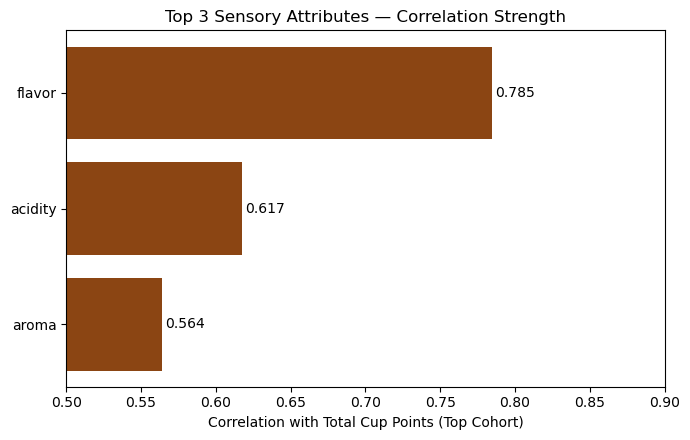

In [11]:
# Horizontal bar chart (Flavor at top if highest)
plt.figure(figsize=(7, 4.5))
plt.barh(corrs.index, corrs.values, color="saddlebrown")
for i, v in enumerate(corrs.values):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.xlabel("Correlation with Total Cup Points (Top Cohort)")
plt.title("Top 3 Sensory Attributes — Correlation Strength")
plt.xlim(0.5, 0.9)
plt.tight_layout()
plt.show()

# Identify top attribute
best_attr = corrs.idxmax()
best_val = corrs.max()

##### **FIGURE 2: Top 3 Sensory Attributes — Correlation Strength**
We deduced that among the top 10% of coffees, flavor had the strongest correlation with total cup points (overall rating), making it the most influential sensory attribute. Aroma and acidity also contributed, but to a slightly lesser extent.

### ***How have average coffee flavor scores changed across different harvest years?***

To understand flavor trends over time, we compared the average flavor scores by harvest year. This revealed whether coffee flavor ratings improved, declined, or remained stable across different harvest seasons.

In [12]:
# Extract grading year
df['grading_year'] = df['grading_date'].astype(str).str.split().str[-1]
df['grading_year'] = pd.to_numeric(df['grading_year'], errors='coerce')

# Replace obvious bad harvest_year values
bad_values = ['NA', 'mmm', 'TEST', 'Abril - Julio', 'Mayo a Julio']
df['harvest_year'] = df['harvest_year'].replace(bad_values, pd.NA)

# Convert harvest_year to numeric and fill with grading_year
df['harvest_year'] = pd.to_numeric(df['harvest_year'], errors='coerce')
df['harvest_year'] = df['harvest_year'].fillna(df['grading_year'])

# Convert flavor to numeric
df['flavor'] = pd.to_numeric(df['flavor'], errors='coerce')

<Figure size 1200x600 with 0 Axes>

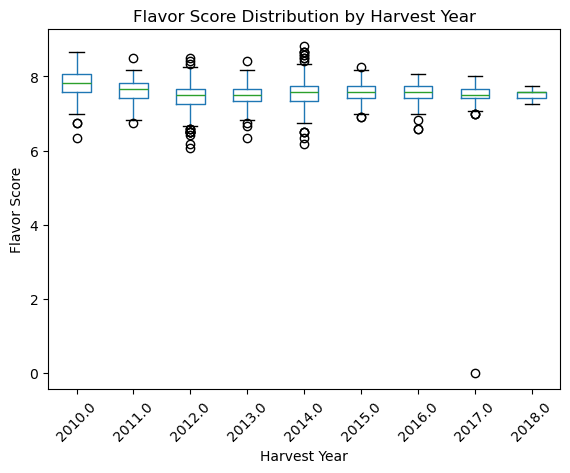

In [13]:
plt.figure(figsize=(12,6))
df.boxplot(column='flavor', by='harvest_year', grid=False)

plt.title("Flavor Score Distribution by Harvest Year")
plt.suptitle("")  # removes the automatic 'Boxplot grouped by harvest_year'
plt.xlabel("Harvest Year")
plt.ylabel("Flavor Score")
plt.xticks(rotation=45)
plt.show()

##### **FIGURE 3: Flavor Score Distribution by Harvest Year**
By observing the data through multiple boxplots, we can clearly discern that outliers are more common in the earlier harvest years but become less frequent over time. This suggests that coffee producers have become more consistent in their growing and processing methods, resulting in flavor scores that are more stable and uniform across different countries. With only occasional exceptions, we can expect a more consistent flavor profile from coffees across various brands in recent years.

### ***Which processing method scores highest in flavor?***

Coffee can be processed through several methods — such as washed, pulped, natural, and honey, or even a combination of these. These methods can influence the final flavor profile of the coffee. We wanted to determine which processing method is associated with the highest flavor scores. To do this, we compared the distribution of flavor ratings across the processing methods and identified which method yielded the highest median and average flavor.

#### **Step 1 - Drop rows with no values in 'processing_method' column**
It is not uncommon for datasets to be incomplete with missing or undefined data. These data can lead to biasd and inaccurate conclusions, thus compromising the integrity of the dataset. Dropping rows and columns depends on the proportion of missing values. It is recommended to drop a column if greater than 50%-80% of its values are missing or undefined. 

In [14]:
# Total number of rows in dataset
df.shape[0]

1339

In [15]:
# Total number of rows with nan values in 'processing_method' column
df["processing_method"].isna().sum()

np.int64(170)

In [16]:
# New DataFrame variable created - main DataFrame with rows containing nan values in 'processing_method' column dropped
method_dropped = df.dropna(subset=["processing_method"])

# Checking value_counts of 'processing_method' column of new DataFrame variable
method_dropped["processing_method"].value_counts()

processing_method
Washed / Wet                 815
Natural / Dry                258
Semi-washed / Semi-pulped     56
Other                         26
Pulped natural / honey        14
Name: count, dtype: int64

#### **Step 2 - Calculate mean flavor scores of each processing method and chart results**

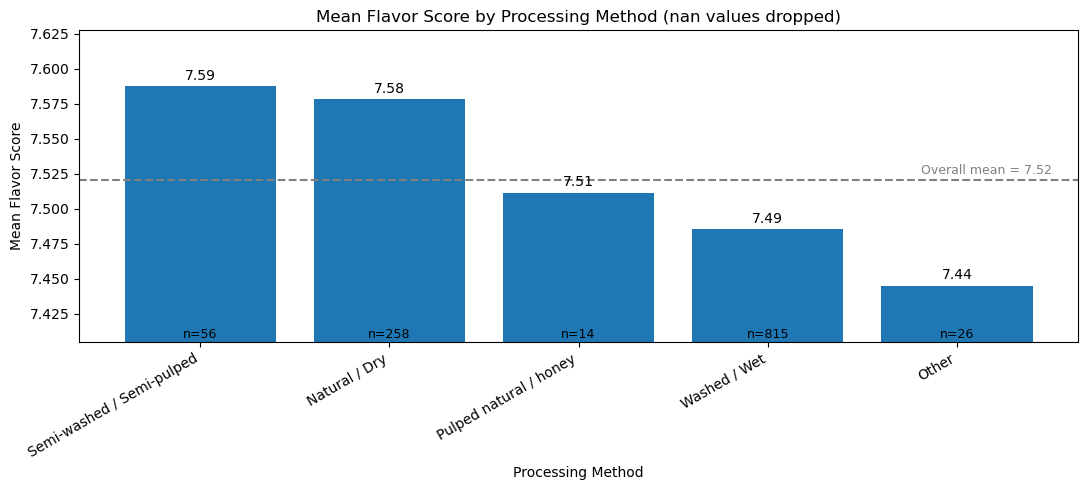

In [17]:
# Calculate mean flavor and counts
method_stats = (
    method_dropped.groupby("processing_method")["flavor"]
      .agg(mean_flavor="mean", n="count")
      .sort_values("mean_flavor", ascending=False)
)

# Extract values for plotting
labels = method_stats.index.tolist()
means = method_stats["mean_flavor"].values
counts = method_stats["n"].values

# Zoom in to emphasize differences
y_min = means.min()
y_max = means.max()
pad = max(0.05, 0.1 * (y_max - y_min))

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, means)

# Add labels for means and counts
for i, bar in enumerate(bars):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + pad*0.05, f"{h:.2f}", 
             ha="center", va="bottom")
    plt.text(bar.get_x() + bar.get_width()/2, y_min - pad*0.6, f"n={counts[i]}",
             ha="center", va="top", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.xlabel("Processing Method")
plt.ylabel("Mean Flavor Score")
plt.title("Mean Flavor Score by Processing Method (nan values dropped)")

# Add overall mean reference line
overall_mean = df["flavor"].mean()
plt.axhline(overall_mean, linestyle="--", color="gray")
plt.text(len(labels)-0.5, overall_mean + pad*0.05,
         f"Overall mean = {overall_mean:.2f}",
         ha="right", va="bottom", fontsize=9, color="gray")

# Zoom in on range
plt.ylim(y_min - pad*0.8, y_max + pad*0.8)

plt.tight_layout()
plt.show()

##### **FIGURE 4: Mean Flavor Score by Processing Method**
It can be inferred from the data that...

### ***What is the relationship between a coffee’s country of origin, the altitude where it is grown, and its flavor score?***

Next, we wanted to determine whether altitude is related to flavor score, and how that relationship appeared across common altitude ranges. Rather than simply compare averages, we examined the full distribution of flavor scores within each altitude band to identify where scores clustered and how much they varied.

In [18]:
# Flavor (numeric)
df["flavor"] = pd.to_numeric(df.get("flavor"), errors="coerce")

# Country (optional, kept tidy for context or later use)
if "country_of_origin" in df.columns:
    df["country"] = df["country_of_origin"].astype(str).str.strip()
else:
    df["country"] = df.get("region", "").astype(str).str.strip()

# Build one numeric altitude column (meters)
alt = pd.Series(np.nan, index=df.index, dtype="float")

# 1) use altitude_mean_meters if present
if "altitude_mean_meters" in df.columns:
    alt = pd.to_numeric(df["altitude_mean_meters"], errors="coerce")

# 2) else try mean of low/high if present
if alt.isna().all() and {"altitude_low_meters","altitude_high_meters"}.issubset(df.columns):
    lo = pd.to_numeric(df["altitude_low_meters"], errors="coerce")
    hi = pd.to_numeric(df["altitude_high_meters"], errors="coerce")
    alt = (lo + hi) / 2

# 3) else parse free-text 'altitude' like "1200-1800" or "1,700"
if alt.isna().all() and "altitude" in df.columns:
    def _num(x):
        try:
            return float(x)
        except:
            return np.nan
    s = df["altitude"].astype(str).str.replace(",", "")
    def parse_alt(v):
        if "-" in v:
            parts = [p.strip() for p in v.split("-")]
            vals = [_num(p) for p in parts if p]
            return np.nan if not vals else np.mean(vals)
        return _num(v)
    alt = s.map(parse_alt)

df["altitude_m"] = alt

# Keep valid rows (all three fields available and > 0 where numeric)
keep = df[["country", "altitude_m", "flavor"]].dropna()
keep = keep[(keep["flavor"] > 0) & (keep["altitude_m"] > 0)].copy()

# Create ordered altitude bands
labels = ["<1200 m", "1200–1599 m", "1600–1999 m", "≥2000 m"]
bins = [-np.inf, 1200, 1600, 2000, np.inf]
keep["alt_band"] = pd.cut(keep["altitude_m"], bins=bins, labels=labels, right=False)

print(f"Usable rows: {len(keep)}")
keep.head()

Usable rows: 1108


,country,altitude_m,flavor,alt_band
0,Ethiopia,2075.0,8.83,≥2000 m
1,Ethiopia,2075.0,8.67,≥2000 m
2,Guatemala,1700.0,8.50,1600–1999 m
3,Ethiopia,2000.0,8.58,≥2000 m
4,Ethiopia,2075.0,8.50,≥2000 m


In [19]:
def parse_alt(v):
    v = str(v).replace(",", "").strip().lower()
    
    # Handle ranges like "1200-1800 ft"
    if "-" in v:
        parts = [p.strip() for p in v.split("-")]
        nums = []
        for p in parts:
            try:
                nums.append(float("".join(c for c in p if c.isdigit() or c == ".")))
            except:
                pass
        if nums:
            avg = sum(nums) / len(nums)
            return avg * 0.3048 if "ft" in v else avg
    
    # Single value with feet
    if "ft" in v or "feet" in v:
        num = "".join(c for c in v if c.isdigit() or c == ".")
        return float(num) * 0.3048
    
    # Single value with meters
    if "m" in v:
        num = "".join(c for c in v if c.isdigit() or c == ".")
        return float(num)
    
    # Plain number → assume meters
    try:
        return float(v)
    except:
        return np.nan

print(df[df["altitude"].astype(str).str.contains("ft", case=False, na=False)][["altitude", "altitude_m"]].head(10))

         altitude  altitude_m
13        2000 ft    609.6000
51         1400ft    426.7200
148      5000 ft.   1524.0000
189  3600-6200 ft   1493.5200
190  4400-4700 ft   1386.8400
292        4921ft   1499.9208
303       2800 ft    853.4400
372      4600 ft.   1402.0800
473      4600 ft.   1402.0800
509       2800 ft    853.4400


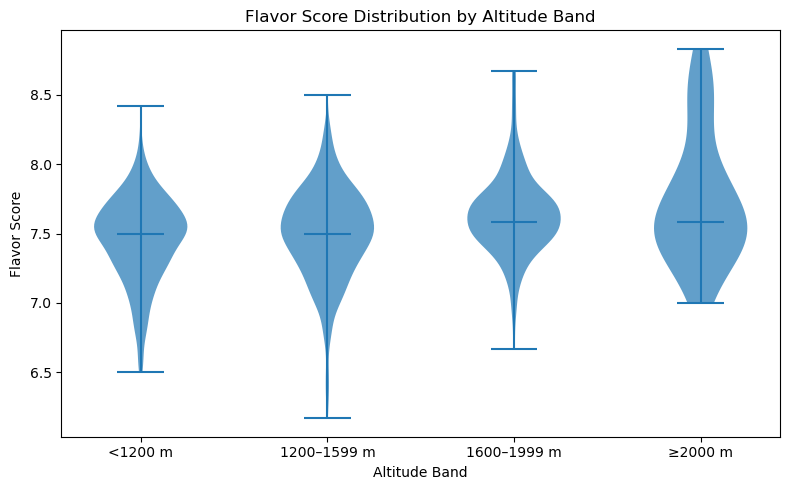

In [20]:
# Build data arrays per band (keeps the code independent of any other charts)
data = [keep.loc[keep["alt_band"] == lab, "flavor"].dropna().values for lab in labels]

plt.figure(figsize=(8, 5))
vp = plt.violinplot(
    dataset=data,
    showmeans=False,
    showmedians=True,     # show the median line
    showextrema=True
)

# X-axis labels
plt.xticks(ticks=range(1, len(labels)+1), labels=labels)
plt.xlabel("Altitude Band")
plt.ylabel("Flavor Score")
plt.title("Flavor Score Distribution by Altitude Band")

# Slightly thinner median line (optional cosmetic)
for b in vp['bodies']:
    b.set_alpha(0.7)

plt.tight_layout()
plt.show()

##### **FIGURE 5: Flavor Score Distribution by Altitude Band**
The above violin plot chart illustrates that flavor scores increase at higher altitude bands, with the highest medians in the 1600–1999 m and ≥2000 m ranges. This indicates a clear positive relationship between altitude and flavor score, with higher elevations generally producing more flavorful coffee.

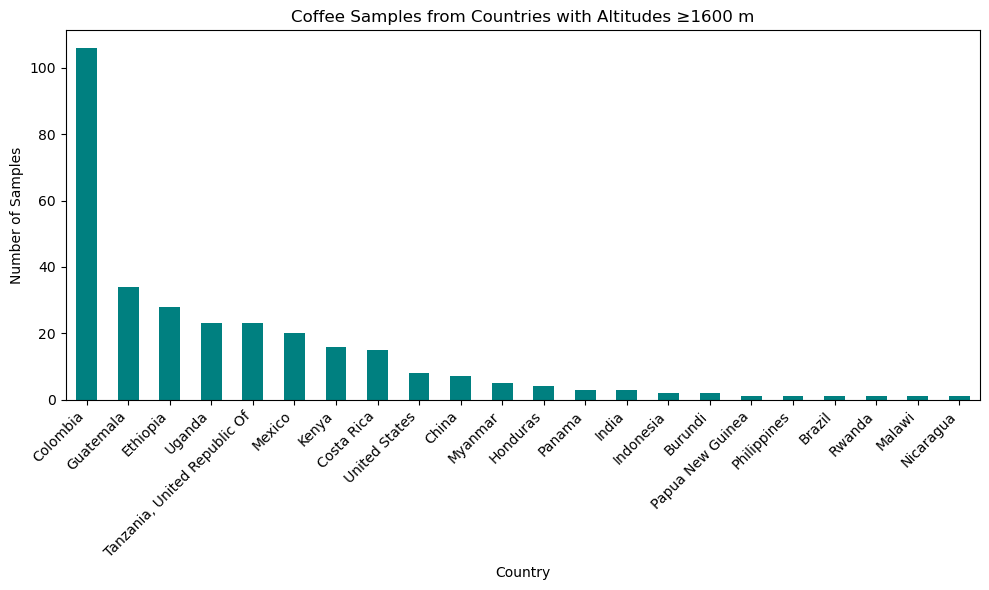

In [21]:
# Filter only rows at or above 1600 m
high_alt = keep[keep["altitude_m"] >= 1600]

# Count how many samples per country
country_counts = high_alt["country"].value_counts().sort_values(ascending=False)

# --- Plot ---
plt.figure(figsize=(10,6))
country_counts.plot(kind="bar", color="teal")

plt.title("Coffee Samples from Countries with Altitudes ≥1600 m")
plt.xlabel("Country")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### **FIGURE 6: Coffee Samples from Countries with Altitudes ≥1600 m**
This simple bar chart presents the comparison of number of coffee samples produced by the group of countries in this dataset with altitudes ≥1600 m, from greatest to least. Colombia distinguished its prominence in this chart with nearly 150 samples.   

### **4. Review of Analysis**

Analysis of the dataset reveals a clear progression in coffee quality and the factors that distinguish top‑performing samples. The distribution of total sensory scores (Figure 1) shows that coffees above the 90th percentile cutoff (≥56.8) form a distinct elite group. Within this group, flavor emerges as the strongest driver of overall cup points (Figure 2), with aroma and acidity contributing but less decisively. Over time, variability in flavor scores has decreased (Figure 3), indicating that producers have refined cultivation and grading practices, resulting in more consistent outcomes across harvest years.

Processing style further shapes flavor outcomes (Figure 4): semi‑washed (7.59) and natural dry (7.58) methods achieve the highest average flavor scores, slightly outperforming pulped natural (7.51) and washed (7.49), while other methods trail at 7.44. This suggests that less intensive or minimally interventionist processing tends to preserve flavor integrity more effectively. Environmental conditions also play a critical role (Figure 5), with coffees grown above 1600 meters consistently achieving stronger flavor scores, reinforcing the positive link between altitude and cup quality. Finally, country‑level comparisons (Figure 6) highlight the prominence of high‑altitude production in shaping sensory excellence, with certain regions contributing disproportionately to the pool of high‑scoring samples.

Taken together, these findings point to a steady refinement in grading practices, a strong quality advantage for high‑altitude coffees, and a meaningful influence of processing style on flavor outcomes. Flavor remains the defining attribute of top‑tier coffees, while altitude and processing choices provide the environmental and technical levers that elevate certain samples above the rest.
